# Satellite Dataset Generation #

## Import Files & APIs ##

Note: Since the raw data is around 9 GB total, the raw data is stored on my (James's) local machine. If the raw data needs to be accessed, contact me by phone or email.

Additionally, the range of the dataset is from 2017-01-01 to 2022-09-23. There were some issues with downloading the data, so the data past 2022-09-23 could not be accessed.

Data was obtained from https://podaac.jpl.nasa.gov/dataset/CYGNSS_L3_SOIL_MOISTURE_V1.0#

In [1]:
from glob import glob
from xarray import open_mfdataset
from warnings import filterwarnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime
import math
import os

import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
filterwarnings('ignore')

In [2]:
sat_data = "./complete_satellite_data/ucar*.nc4"
sat_data_f = sorted(glob(sat_data)) # finds files recursively

sat_ds = open_mfdataset(sat_data_f, combine="by_coords")
sat_ds

<xarray.Dataset>
Dimensions:         (time: 2091, timeslices: 4, lat: 252, lon: 802, startstop: 2)
Coordinates:
  * time            (time) datetime64[ns] 2017-03-18T12:00:00 ... 2022-12-10T...
Dimensions without coordinates: timeslices, lat, lon, startstop
Data variables:
    SM_subdaily     (time, timeslices, lat, lon) float32 dask.array<chunksize=(1, 4, 252, 802), meta=np.ndarray>
    SIGMA_subdaily  (time, timeslices, lat, lon) float32 dask.array<chunksize=(1, 4, 252, 802), meta=np.ndarray>
    longitude       (time, lat, lon) float32 dask.array<chunksize=(1, 252, 802), meta=np.ndarray>
    latitude        (time, lat, lon) float32 dask.array<chunksize=(1, 252, 802), meta=np.ndarray>
    timeintervals   (time, startstop, timeslices) timedelta64[ns] dask.array<chunksize=(1, 2, 4), meta=np.ndarray>
    SM_daily        (time, lat, lon) float32 dask.array<chunksize=(1, 252, 802), meta=np.ndarray>
    SIGMA_daily     (time, lat, lon) float32 dask.array<chunksize=(1, 252, 802), meta=np.ndarray>
Attributes: (12/46)
    source:                              ucar_cu_cygnss_sm_v1_2017_077.nc
    id:                                  PODAAC-CYGNU-L3SM1
    ShortName:                           CYGNSS_L3_SOIL_MOISTURE_V1.0
    title:                               CYGNSS Level 3 Soil Moisture from UC...
    summary:                             The CYGNSS Level 3 Soil Moisture Pro...
    comment:                             Dataset created by UCAR and CU Boulder
    ...                                  ...
    build_dmrpp_metadata.build_dmrpp:    3.20.9-91
    build_dmrpp_metadata.bes:            3.20.9-91
    build_dmrpp_metadata.libdap:         libdap-3.20.8-41
    build_dmrpp_metadata.configuration:  \n# TheBESKeys::get_as_config()\nAll...
    build_dmrpp_metadata.invocation:     build_dmrpp -c /tmp/conf_oWLD -f /tm...
    history_json:                        [{"$schema":"https:\/\/harmony.earth...

## Distance to stations ##

In [3]:
latitudes = sat_ds['latitude'].values
longitudes = sat_ds['longitude'].values

lat_list = [float(item[0]) for item in latitudes[0]]
lon_list = [float(item) for item in longitudes[0][0]]

In [4]:
# Binary search
def search(val, lat_lon_list):
    low = 0
    high = len(lat_lon_list) - 1
    mid = 0
    
    while low <= high:
        mid = (low + high) // 2
        if lat_lon_list[mid] < val:
            low = mid + 1
        elif lat_lon_list[mid] > val:
            high = mid - 1
        else:
            return mid
    return mid

In [5]:
# Finds the index of the closest longitude/latitude in their corresponding lists using binary search
def find_closest_coords(stat_lats, stat_lons):
    assert len(stat_lats) == len(stat_lons)
    
    closest_coord_idx = []
    closest_coord = []
    for i in range(len(stat_lats)):
        lat_idx = search(stat_lats[i], lat_list)
        lon_idx = search(stat_lons[i], lon_list)
        closest_coord_idx.append((lat_idx, lon_idx))
        closest_coord.append((lat_list[lat_idx], lon_list[lon_idx]))
    
    return closest_coord_idx, closest_coord

In [6]:
# Haversine formula to calculate distance
def haversine(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])

    # Difference in coordinates
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine formula
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

    # Earth's radius in kilometers (can be adjusted for different units)
    R = 6371.0
    distance = R * c

    return distance

In [7]:
# Make dataframe from station data
def make_stat_dist_df(closets_coord_function):
    stat_ids = ['5', '1', '6', '4', '2', '3']
    stations_data = [
        {'stat_lat': 30.3989, 'stat_lon': -98.6105},
        {'stat_lat': 30.4193, 'stat_lon': -98.8046},
        {'stat_lat': 30.4421, 'stat_lon': -98.8427},
        {'stat_lat': 30.4600, 'stat_lon': -98.9407},
        {'stat_lat': 30.2454, 'stat_lon': -98.7059},
        {'stat_lat': 30.2758, 'stat_lon': -98.7242}
    ]
    stat_df = pd.DataFrame(stations_data, index=stat_ids)
    stat_df.index.name = 'stat_id'
    
    stat_lats = list(stat_df['stat_lat'])
    stat_lons = list(stat_df['stat_lon'])
    
    closest_coord_idx, closest_coord = closets_coord_function(stat_lats, stat_lons)
    stat_df['closest_lat'] = [round(item[0], 4) for item in closest_coord]
    stat_df['closest_lon'] = [round(item[1], 4) for item in closest_coord]
    stat_df['closest_idx'] = closest_coord_idx
    
    stat_df['distance'] = stat_df.apply(
        lambda row: haversine(
            row['stat_lat'], 
            row['stat_lon'], 
            row['closest_lat'], 
            row['closest_lon']), 
        axis=1, 
        result_type='expand'
    )
    
    return stat_df

In [8]:
# Dataframe displays each station's coordinates, the closest available coordinates from the satellite
# data, the closest coordinates' corresponding indices, and the distance between the station and closest 
# available coordinate.
stat_df = make_stat_dist_df(find_closest_coords)
stat_df

,stat_lat,stat_lon,closest_lat,closest_lon,closest_idx,distance
stat_id,,,,,,
5,30.3989,-98.6105,30.6384,-98.4025,"(229, 98)",33.259596
1,30.4193,-98.8046,30.6384,-99.1494,"(229, 96)",41.038982
6,30.4421,-98.8427,30.6384,-99.1494,"(229, 96)",36.594775
4,30.4600,-98.9407,30.6384,-99.1494,"(229, 96)",28.158833
2,30.2454,-98.7059,29.9863,-98.4025,"(227, 98)",41.008144
3,30.2758,-98.7242,29.9863,-98.4025,"(227, 98)",44.647604


## Check if coordinates are correct ##

In [9]:
global_sm = sat_ds['SM_daily'].values

In [10]:
def draw_map(stat_df):
    # Create map
    fig = plt.figure(figsize=(16, 12), edgecolor='w')

    m = Basemap(width=5000000,height=3500000,
                resolution='l',projection='cass',\
                llcrnrlon=-99.5,llcrnrlat=29.75,urcrnrlon=-98,urcrnrlat=31,\
                lat_ts=0,lat_0=30.267153,lon_0=-97.743057) 
    xi, yi = longitudes[1,217:247,80:110], latitudes[1,217:247,80:110]
    cs = m.pcolor(xi, yi, global_sm[1,217:247,80:110], latlon = True)

    m.drawcoastlines()
    m.drawstates()
    m.drawcountries()

    # Plot points
    colors = ['b', 'g', 'y', 'c', 'w', 'm']
    for index, row in stat_df.iterrows():
        stat_id = int(index)
        stat_lon, stat_lat = row['stat_lon'], row['stat_lat']
        closest_lon, closest_lat = row['closest_lon'], row['closest_lat']

        stat_xpt, stat_ypt = m(stat_lon,stat_lat)
        m.plot(stat_xpt, stat_ypt, colors[stat_id - 1] + 'o')
        plt.text(
            stat_xpt+1000,
            stat_ypt+1000,
            'Station %d' % (int(index)), 
            c=colors[stat_id - 1]
        )

        closest_xpt, closest_ypt = m(closest_lon,closest_lat)
        m.plot(closest_xpt, closest_ypt, colors[stat_id - 1] + 'o')
        plt.text(
            closest_xpt+1000,
            closest_ypt+1000,
            'Closest to Station %d' % (stat_id), 
            c=colors[stat_id - 1]
        )

    opt_lon, opt_lat = -98.7759, 30.3118
    opt_xpt, opt_ypt = m(opt_lon, opt_lat)
    m.plot(opt_xpt, opt_ypt, 'ro')
    plt.text(
        opt_xpt+1000,
        opt_ypt+1000,
        'Optimal point', 
        c='r'
    )


    cbar = m.colorbar(cs, location='bottom', pad="10%")
    cbar.set_label('$cm^3 cm^{-3}$')

    plt.title('Soil Moisture CyGNSS')
    plt.show()

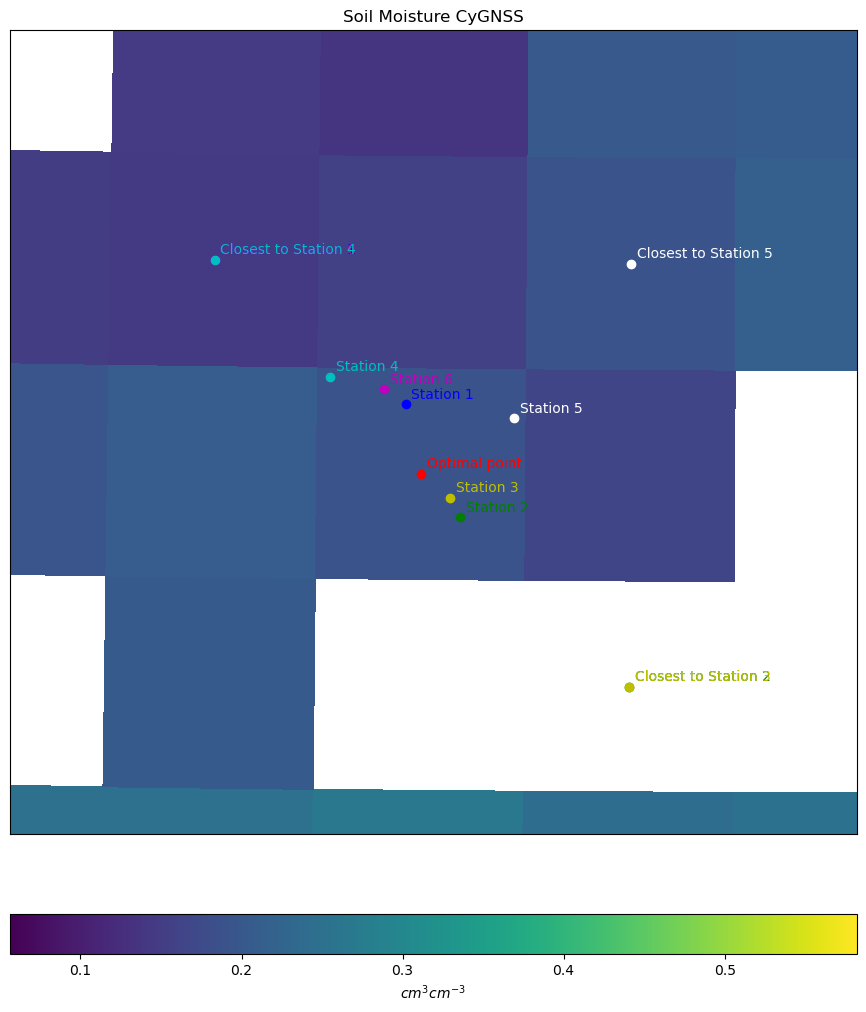

In [11]:
draw_map(stat_df)

As seen with the above map, the points that we chose were completely wrong. We need to find the coordinate of the square that contains all of the stations. Need to debug original code!

In [12]:
def new_closest_coords(stat_lats, stat_lons):
    assert len(stat_lats) == len(stat_lons)
    
    closest_coord_idx = []
    closest_coord = []
    for i in range(len(stat_lats)):
        stat_lat = stat_lats[i]
        stat_lon = stat_lons[i]
        
        lat_idx = min(
            range(len(lat_list)), 
            key=lambda j: abs(lat_list[j] - stat_lat)
        )
        lon_idx = min(
            range(len(lon_list)), 
            key=lambda j: abs(lon_list[j] - stat_lon)
        )
        
        closest_coord_idx.append((lat_idx, lon_idx))
        closest_coord.append((lat_list[lat_idx], lon_list[lon_idx]))
    
    return closest_coord_idx, closest_coord

In [13]:
new_stat_df = make_stat_dist_df(new_closest_coords)
new_stat_df

,stat_lat,stat_lon,closest_lat,closest_lon,closest_idx,distance
stat_id,,,,,,
5,30.3989,-98.6105,30.3118,-98.7759,"(228, 97)",18.592113
1,30.4193,-98.8046,30.3118,-98.7759,"(228, 97)",12.266494
6,30.4421,-98.8427,30.3118,-98.7759,"(228, 97)",15.842545
4,30.4600,-98.9407,30.3118,-98.7759,"(228, 97)",22.835190
2,30.2454,-98.7059,30.3118,-98.7759,"(228, 97)",9.984826
3,30.2758,-98.7242,30.3118,-98.7759,"(228, 97)",6.376777


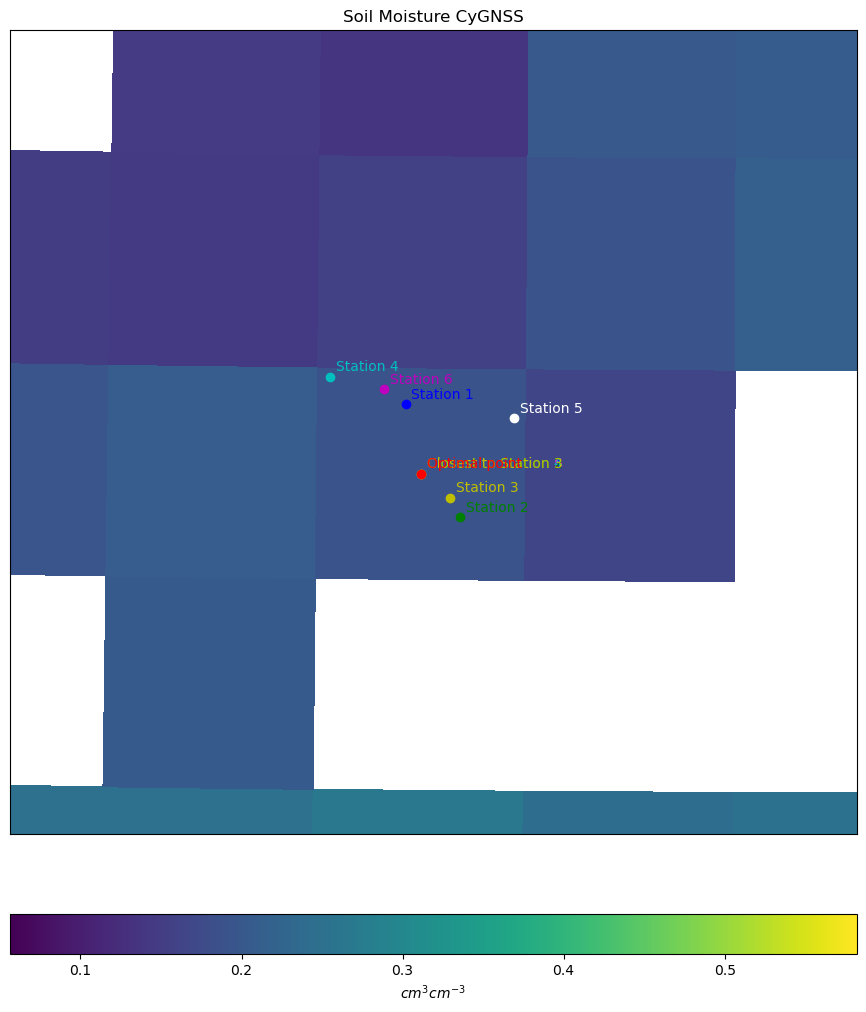

In [14]:
draw_map(new_stat_df)

In [15]:
stat_df = new_stat_df

## Generate soil moisture dataframes for each station ##

In [16]:
# Soil moisture values
global_sm = sat_ds['SM_daily'].values

In [17]:
# Get dates for indexing pandas dataframe
START_YEAR = 2017
index_dates = []
for i in range(1, 2092):
    year = START_YEAR + i // 365
    # Leap year 2020 is taken into account
    day = i % 365 if year % 4 > 0 else i % 366
    index_dates.append(datetime.datetime(year, 1, 1) + datetime.timedelta(day - 1))
index_dates = np.array(index_dates)

In [18]:
# Obtain the soil moisture levels for the given station
def sm_lvl_list(stat_id):
    lat, lon = stat_df.loc[stat_id]['closest_idx']
    l3_sm = [global_sm[i][lat][lon] for i in range(0,2091)]
    return np.array(l3_sm)

In [19]:
# Generate soil moisture dataframe that also includes distance data
def create_sm_df(stat_id):
    sm_df = pd.DataFrame(index=index_dates)
    sm_df.index.name = "Date"

    sm_data = sm_lvl_list(stat_id)
    dist_data = np.repeat(stat_df.loc[stat_id]['distance'], len(sm_data))

    sm_df['soil_moisture'] = sm_data
    sm_df['distance'] = dist_data

    return sm_df

In [20]:
# Convert soil moisture dataframes into CSV files
for i in range(1, 7):
    stat_id = str(i)
    
    file_name = "Station" + stat_id + "_Satellite.csv"
    target_file = os.path.join("./satellite_data_csv", file_name)
    f = open(target_file, "w")
    
    sm_df = create_sm_df(stat_id)
    sm_df.to_csv(f)
    
    f.close()